In [1]:
from __future__ import annotations

import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from tools.robots.robot import Robot
from tools.robots.double_integrator import DoubleIntegrator
from tools.robots.single_integrator import SingleIntegrator

from tools.planners.mcgs import MCGSPlanner, NodePayload, EdgePayload
from tools.envs.frozen_lake_continuous import FrozenLakeEnv

from tools.utils.plot_graph import plot_graph_2d, plot_spacetime_graph_3d

import rustworkx as rx
from rustworkx.visualization import mpl_draw
# from rustworkx import Pos2DMapping
# %matplotlib widget



In [2]:
np.random.seed(1234)

In [3]:
max_velocity = 10.0
rob = SingleIntegrator(id=0, name="SingleIntegrator", dt=.1, max_velocity=max_velocity)

demo_graph = rx.PyDiGraph()
root_state = {'position': np.array([0.0, 0.0]), 'time': np.array(0.0)}

rob.state = root_state
print(rob)

root_encoded_state = rob.encode_state(root_state)
root_id = demo_graph.add_node(NodePayload(state=root_state, state_encoded=root_encoded_state))
demo_graph[root_id].index = root_id

    


Robot SingleIntegrator (ID: 0) with state {'position': array([0., 0.]), 'time': array(0.)} and bounding box None


In [4]:
def reward_function(state, debug=False):
    # Example reward function: negative distance to the goal position
    goal_position = 1*np.array([1.0, 1.0])  # Define goal position
    reward = 2 - .1*state['time']- np.linalg.norm(state['position'] - goal_position, ord=2)
    if debug:
        print(f"Reward: {reward}")
    return reward

In [5]:
mcgs_planner = MCGSPlanner(robot=rob, 
                           reward_function=reward_function,
                           max_iterations=1000, 
                           kappa=0.9, 
                           alpha=0.8,
                           k=10,
                           radius_threshold=0.05,)

Node 0 updated: N=1, Q=0.59, U=0.59


Node 0 updated: N=1, Q=0.59, U=0.59
---- Iteration 1/3 ----
Selected node: 0 via []
Found 0 neighbors: []
Expanded to node(s): [1]
Node 1 updated: N=1, Q=0.13, U=0.13
Updating edge value from node 0 to child node 1
Backpropagating from node 0 to parent nodes []
Node 0 updated: N=2, Q=0.36, U=0.59
---- Iteration 2/3 ----
Selected node: 1 via [0]
Found 0 neighbors: []
Expanded to node(s): [2]
Node 2 updated: N=1, Q=0.05, U=0.05
Updating edge value from node 1 to child node 2
Backpropagating from node 1 to parent nodes [0]
Node 1 updated: N=2, Q=0.09, U=0.13
Updating edge value from node 0 to child node 1
Backpropagating from node 0 to parent nodes []
Node 0 updated: N=3, Q=0.22, U=0.59
---- Iteration 3/3 ----
Selected node: 2 via [0, 1]
Found 0 neighbors: []
Expanded to node(s): [3]
Node 3 updated: N=1, Q=0.15, U=0.15
Updating edge value from node 2 to child node 3
Backpropagating from node 2 to parent nodes [0, 1]
Node 2 updated: N=2, Q=0.10, U=0.05
Updating edge value from node 1 to ch

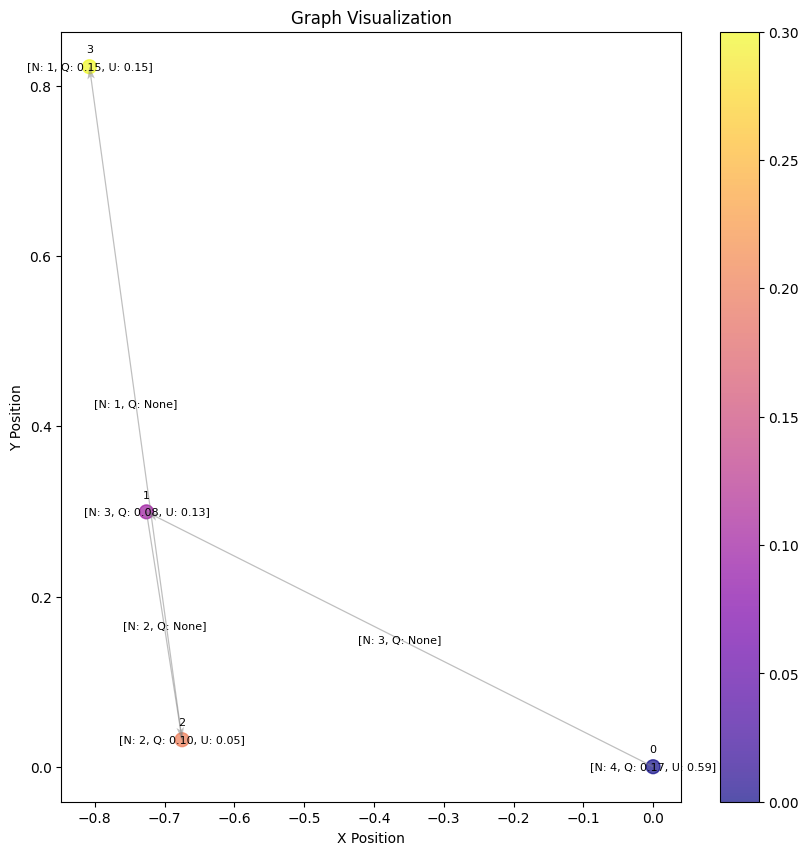

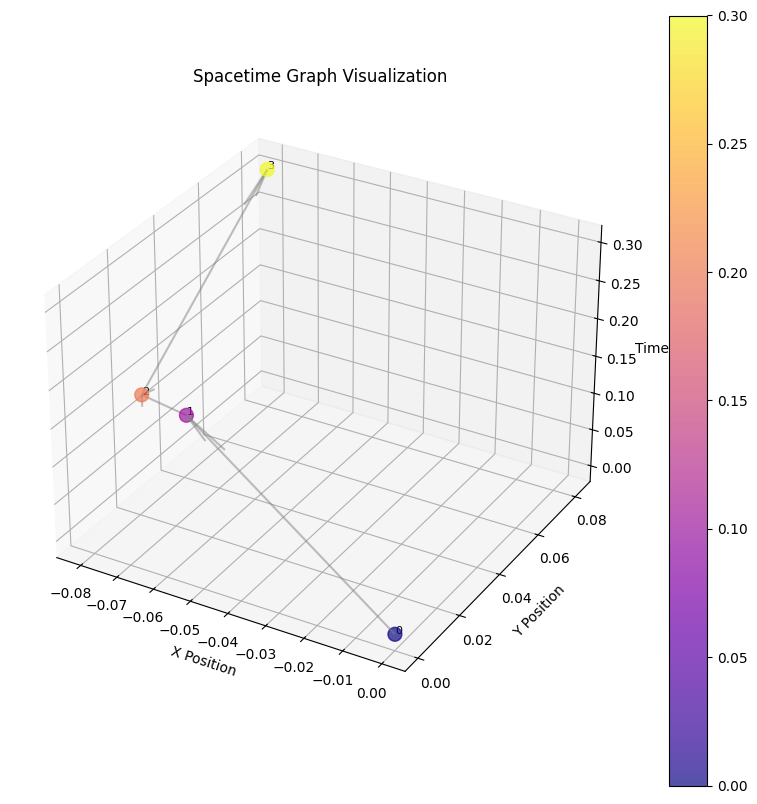

In [6]:
mcgs_planner.reset_graph()
mcgs_planner.plan(iterations=3)
plot_graph_2d(mcgs_planner.graph)
plot_spacetime_graph_3d(mcgs_planner.graph, mcgs_planner.robot)